In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('DATA/cancer_classification.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

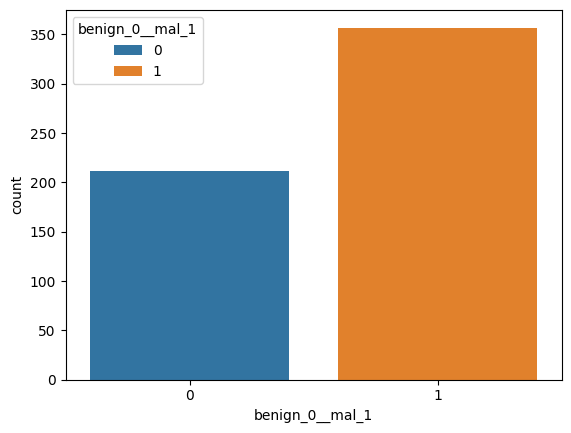

In [7]:
sns.countplot(x='benign_0__mal_1', data=df, hue = 'benign_0__mal_1')

<Axes: >

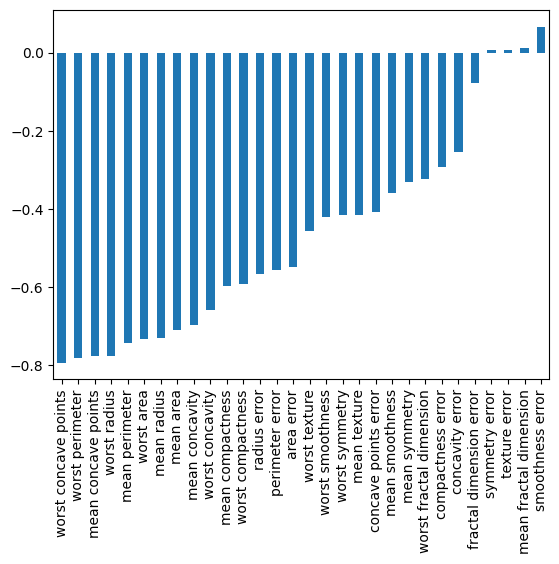

In [10]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar')

<Axes: >

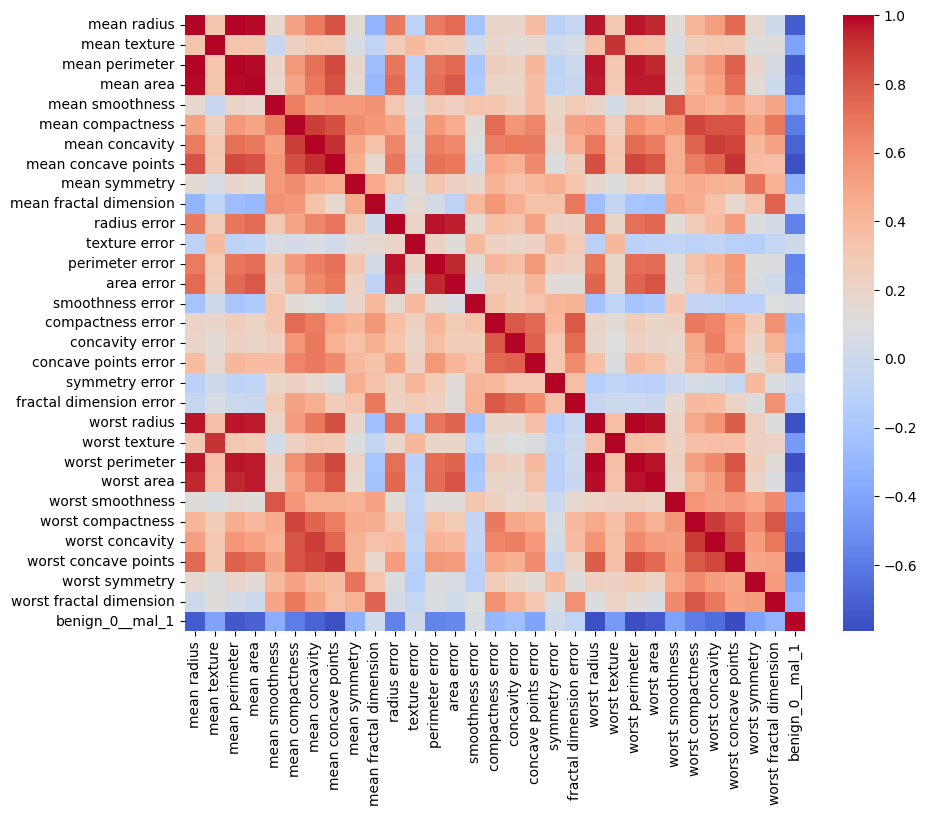

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm')

In [14]:
X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [20]:
X_train.shape

(426, 30)

In [23]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))


model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC', 'Precision', 'Recall', 'f1_score'])

In [24]:
model.fit(X_train_scaled, y_train, epochs=600, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - AUC: 0.7225 - Precision: 0.8372 - Recall: 0.3310 - accuracy: 0.5148 - f1_score: 0.7939 - loss: 0.6887 - val_AUC: 0.9677 - val_Precision: 0.9390 - val_Recall: 0.8750 - val_accuracy: 0.8881 - val_f1_score: 0.7619 - val_loss: 0.4998
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9589 - Precision: 0.9542 - Recall: 0.8991 - accuracy: 0.9085 - f1_score: 0.7771 - loss: 0.4740 - val_AUC: 0.9857 - val_Precision: 0.9651 - val_Recall: 0.9432 - val_accuracy: 0.9441 - val_f1_score: 0.7619 - val_loss: 0.3590
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9692 - Precision: 0.9297 - Recall: 0.9599 - accuracy: 0.9281 - f1_score: 0.7792 - loss: 0.3446 - val_AUC: 0.9900 - val_Precision: 0.9432 - val_Recall: 0.9432 - val_accuracy: 0.9301 - val_f1_score: 0.7619 - val_loss: 0.2595
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9828 - Precision: 0.9375 - Recall: 0.9741 - accuracy: 0.9416 - f1_score: 0.7815 - loss: 0.

<Axes: >

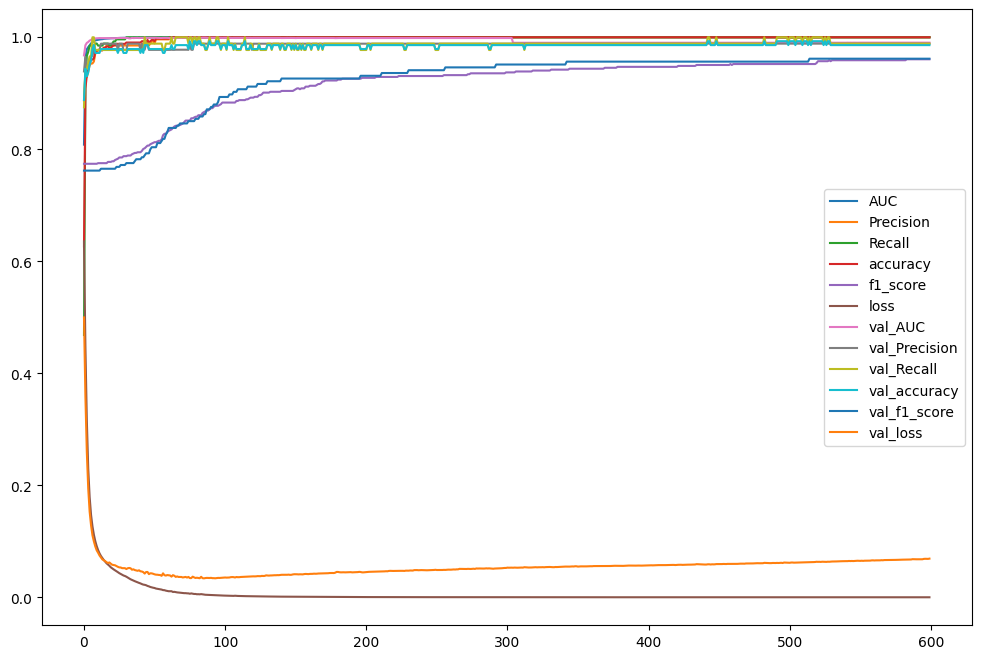

In [25]:
pd.DataFrame(model.history.history).plot(figsize=(12, 8))

In [26]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))


model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC', 'Precision', 'Recall', 'f1_score'])

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [29]:
model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1, callbacks=[early_stop])

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - AUC: 0.7996 - Precision: 0.8888 - Recall: 0.5733 - accuracy: 0.6923 - f1_score: 0.7678 - loss: 0.6334 - val_AUC: 0.9658 - val_Precision: 0.9481 - val_Recall: 0.8295 - val_accuracy: 0.8671 - val_f1_score: 0.7619 - val_loss: 0.4906
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9682 - Precision: 0.9530 - Recall: 0.9346 - accuracy: 0.9316 - f1_score: 0.7624 - loss: 0.4227 - val_AUC: 0.9817 - val_Precision: 0.9639 - val_Recall: 0.9091 - val_accuracy: 0.9231 - val_f1_score: 0.7619 - val_loss: 0.3417
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.9727 - Precision: 0.9445 - Recall: 0.9808 - accuracy: 0.9520 - f1_score: 0.7693 - loss: 0.2982 - val_AUC: 0.9871 - val_Precision: 0.9545 - val_Recall: 0.9545 - val_accuracy: 0.9441 - val_f1_score: 0.7619 - val_loss: 0.2439
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.9814 - Precision: 0.9362 - Recall: 0.9787 - accuracy: 0.9449 - f1_score: 0.7671 - loss: 0

<Axes: >

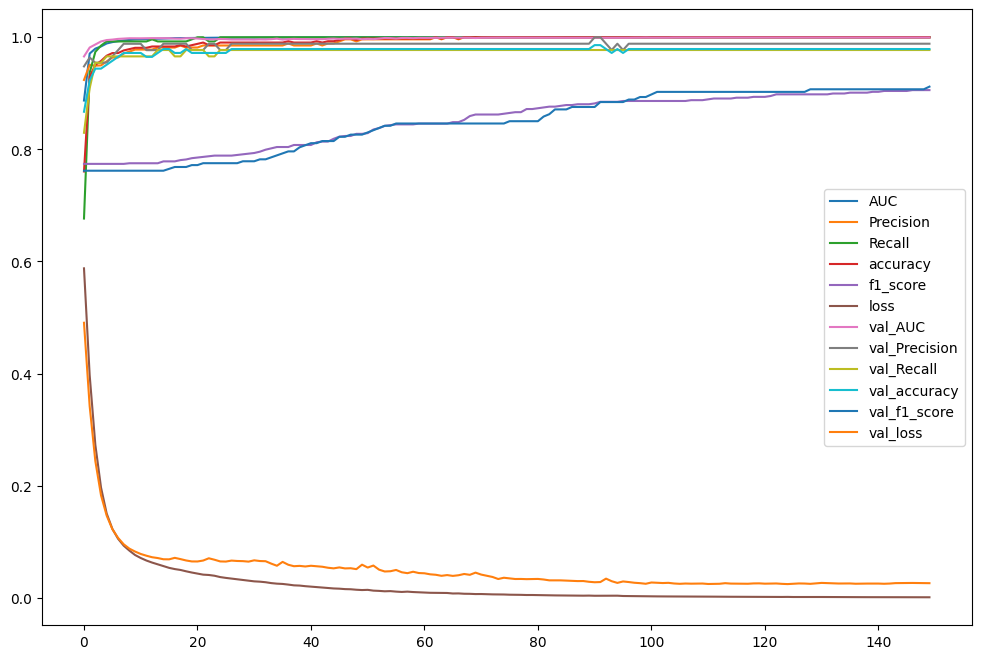

In [30]:
pd.DataFrame(model.history.history).plot(figsize=(12, 8))

In [31]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC', 'Precision', 'Recall', 'f1_score'])

In [32]:
model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1, callbacks=[early_stop])

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - AUC: 0.4802 - Precision: 0.6155 - Recall: 0.5585 - accuracy: 0.4993 - f1_score: 0.7798 - loss: 0.9062 - val_AUC: 0.7210 - val_Precision: 0.7664 - val_Recall: 0.9318 - val_accuracy: 0.7832 - val_f1_score: 0.7619 - val_loss: 0.5947
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.6630 - Precision: 0.7445 - Recall: 0.7153 - accuracy: 0.6569 - f1_score: 0.7863 - loss: 0.7309 - val_AUC: 0.8964 - val_Precision: 0.8247 - val_Recall: 0.9091 - val_accuracy: 0.8252 - val_f1_score: 0.7619 - val_loss: 0.4854
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.7234 - Precision: 0.7413 - Recall: 0.7689 - accuracy: 0.6815 - f1_score: 0.7781 - loss: 0.5816 - val_AUC: 0.9399 - val_Precision: 0.8617 - val_Recall: 0.9205 - val_accuracy: 0.8601 - val_f1_score: 0.7619 - val_loss: 0.4147
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8076 - Precision: 0.7997 - Recall: 0.8450 - accuracy: 0.7711 - f1_score: 0.7683 - loss: 0.

<Axes: >

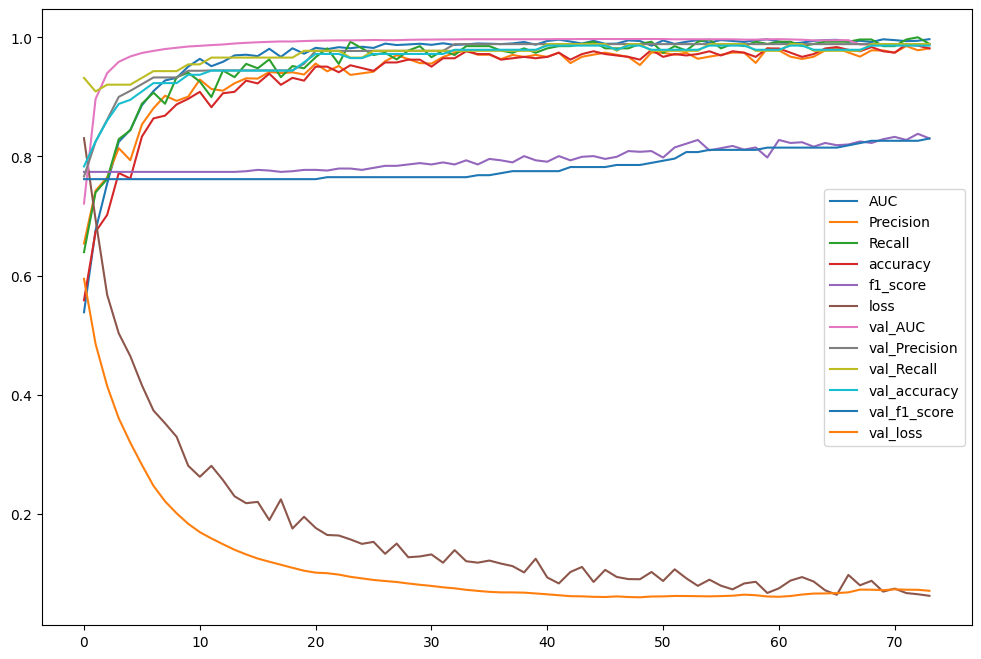

In [33]:
pd.DataFrame(model.history.history).plot(figsize=(12, 8))

In [55]:
pred = (model.predict(X_test_scaled)[:,0] > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [56]:
pred

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0])

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        55
           1       0.99      0.99      0.99        88

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

[[54  1]
 [ 1 87]]
